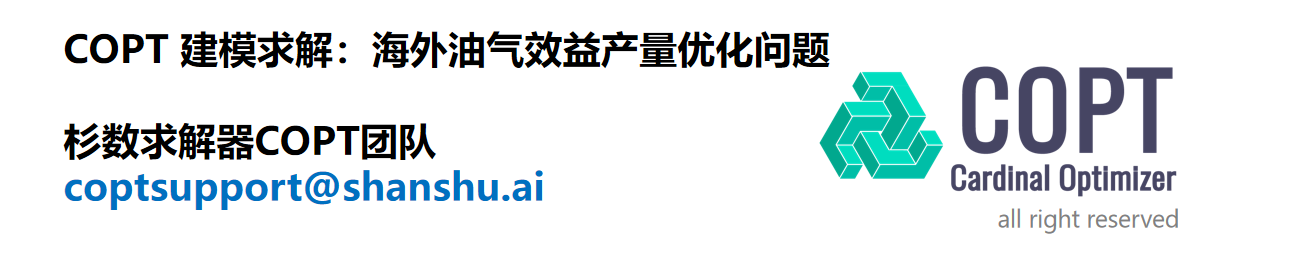

# 海外油气效益产量优化问题代码实现
## 使用 COPT 多目标框架建模求解海外油气效益产量优化问题的步骤

1. **安装依赖（可选）**

2. **导入COPT-Python接口库** `coptpy`

3. **导入数据**
    - 从 `fields.csv` 读取 40 个油田的逐字段参数
    - 从 `model_params.csv` 读取约束门槛参数

4. **创建COPT求解环境与模型**

5. **构建模型：依次添加三要素**
    - **决策变量**：
        - $x_{ij}\in\{0,1\}$：是否开采第 $i$ 区块第 $j$ 个油田 (Binary)
        - $\delta\geq 0$：辅助变量，用于线性化产量偏差目标 $|Q^*-\sum q|$
    - **目标函数**：
        - 产量最大化 
        - 产量偏差最小化 
        - 利润最大化
        - 现金流最大化 
        - 综合风险最小化
    - **约束条件**：
        - 单位操作成本上限
        - 单位付现成本上限
        - 总投资上限
        - 每个区块至少开采 $n_{i}$ 个油田

6. **求解**

7. 查看、分析**结果**


本模型从 40 个候选油田（5 区块 × 8 油田）中选择开采组合，使用 COPT 原生多目标框架 `setObjectiveN` 同时优化产量、产量偏差、利润、现金流、风险 5 个目标，并施加单位成本上限、总投资上限、区块最少开采数等约束。

In [ ]:
# Fetch this case's data files when they are not already next to the notebook.
import os, urllib.parse, urllib.request
BASE = 'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/notebooks/zh/Overseas_Oil_Gas_Benefit_Production_Optimization/'
FILES = [
    'fields.csv',
    'model_params.csv',
    'requirements.txt',
]
for f in FILES:
    if not os.path.exists(f):
        os.makedirs(os.path.dirname(f) or '.', exist_ok=True)
        urllib.request.urlretrieve(BASE + urllib.parse.quote(f), f)
print(len(FILES), 'data file(s) ready')

## 安装依赖
运行下面的单元格，把本案例的依赖装进当前运行环境。不需要切换环境或更换 kernel。

In [3]:
# No conda here; install this case's requirements with pip
!pip install -q -r requirements.txt

## 导入 COPT-Python 接口库

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import coptpy as cp
from coptpy import COPT, quicksum

## 添加模型数据

从 `fields.csv` 读取 40 个油田的逐字段参数（产量、成本、利润、现金流、风险等），从 `model_params.csv` 读取约束门槛参数。

In [7]:
fields = pd.read_csv('fields.csv')
params = pd.read_csv('model_params.csv', index_col=0).squeeze()

# 油田索引与逐字段参数字典
IJ     = [(int(r.block_i), int(r.field_j)) for r in fields.itertuples()]
BLOCKS = sorted(fields['block_i'].unique())
DATA   = {(int(r.block_i), int(r.field_j)): r for r in fields.itertuples()}

C7    = float(params['C7'])                 # 总投资上限
N_REQ = int(params['n_required_per_block']) # 每区块最少开采字段数

print(f"油田数量: {len(IJ)}   区块数: {len(BLOCKS)}")
print(f"产量池总计: {fields['q'].sum()/1e6:.1f} M 吨")
print(f"利润池总计: {fields['p'].sum()/1e8:.1f} ×10⁸ CNY")

油田数量: 40   区块数: 5
产量池总计: 50.3 M 吨
利润池总计: 1875.7 ×10⁸ CNY


## 创建求解环境和求解模型

同时读取模型约束所需的门槛参数 $C_2$（单位操作成本上限）、$C_3$（单位付现成本上限）、$Q^*$（目标产量）。

In [9]:
C2       = float(params['C2'])        # 单位操作成本上限，CNY/吨
C3       = float(params['C3'])        # 单位付现成本上限，CNY/吨
Q_target = float(params['Q_target'])  # 目标产量，吨

env   = cp.Envr(cp.EnvrConfig().set('nobanner', '1'))
model = env.createModel('oil_multiobj')

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素

### 添加决策变量

$x_{ij}\in\{0,1\}$ 表示是否开采第 $i$ 区块第 $j$ 个油田；辅助变量 $\delta\geq 0$ 用于线性化产量偏差目标 $|Q^*-\sum q|$（对应的两条线性化不等式见约束部分）。

In [11]:
# 二元决策变量：是否开采
x = {(i,j): model.addVar(vtype=COPT.BINARY, name=f'x_{i}_{j}') for i,j in IJ}

# 辅助变量：目标 (1*) 线性化 |Q_target - Σq|
dv    = model.addVar(lb=0, name='delta_yield')
q_sum = quicksum(x[i,j] * DATA[i,j].q for i,j in IJ)

### 设置目标函数

使用 `model.setObjectiveN(idx, expr, sense)` 一次性注册 5 个线性目标，再用 `setObjParamN` 为每个目标配置优先级 / 权重 / 容差。

- 产量最大化：$ \max \sum_{i,j} x_{ij}\,q_{ij} \qquad\text{(1)}$
- 产量偏差最小化：$ \min \delta \quad\text{s.t.}\ \delta \geq Q^{*}-\sum_{i,j}x_{ij}q_{ij},\ \ \delta \geq \sum_{i,j}x_{ij}q_{ij}-Q^{*} \qquad\text{(1*)}$
- 利润最大化：$ \max \sum_{i,j} x_{ij}\,p_{ij} \qquad\text{(2)}$
- 现金流最大化：$ \max \sum_{i,j} x_{ij}\,c_{ij} \qquad\text{(3)}$
- 综合风险最小化：$ \min \sum_{i,j} x_{ij}\,r_{ij} \qquad\text{(6)}$

In [14]:
# ── 目标函数表达式 ──
p_sum = quicksum(x[i,j] * DATA[i,j].p for i,j in IJ)
c_sum = quicksum(x[i,j] * DATA[i,j].c for i,j in IJ)
r_sum = quicksum(x[i,j] * DATA[i,j].r for i,j in IJ)

# ── 注册 5 个目标（idx=0..4） ──
model.setObjectiveN(0, q_sum, COPT.MAXIMIZE)   # (1)  产量最大化
model.setObjectiveN(1, dv,    COPT.MINIMIZE)   # (1*) 产量偏差最小化
model.setObjectiveN(2, p_sum, COPT.MAXIMIZE)   # (2)  利润最大化
model.setObjectiveN(3, c_sum, COPT.MAXIMIZE)   # (3)  现金流最大化
model.setObjectiveN(4, r_sum, COPT.MINIMIZE)   # (6)  风险最小化

# ── 优先级示例：利润优先 → 风险次之 → 其余等权加权求和 ──
# priority 越大越先被优化；同 priority 的目标做加权求和
model.setObjParamN(2, "MultiObjPriority", 2)         # 利润：最高优先
model.setObjParamN(4, "MultiObjPriority", 1)         # 风险：次优先
# 目标 0,1,3 保持默认 priority=0，与风险目标分属不同层级

# 为利润目标设置绝对偏差容限：允许偏离最优利润 5×10⁸ CNY，为风险优化留空间
model.setObjParamN(2, "MultiObjAbsTol", 5e8)

print("目标优先级配置：")
print("  idx=2 利润    priority=2  AbsTol=5×10⁸ CNY（利润允许小幅牺牲换取更低风险）")
print("  idx=4 风险    priority=1")
print("  idx=0,1,3     priority=0  （等权加权求和）")

目标优先级配置：
  idx=2 利润    priority=2  AbsTol=5×10⁸ CNY（利润允许小幅牺牲换取更低风险）
  idx=4 风险    priority=1
  idx=0,1,3     priority=0  （等权加权求和）


<font color=#0000FF>
<b>提示：COPT 多目标框架 setObjectiveN</b>
</font>

COPT 通过 `model.setObjectiveN(idx, expr, sense)` 注册多个目标函数，并支持用 `model.setObjParamN(idx, param, value)` 为每个目标单独配置求解策略：

| 参数名 | 含义 | 默认值 |
|---|---|---|
| `MultiObjPriority` | **优先级**，值越大越优先；同优先级目标做加权求和，高优先级目标先求最优，再在允许偏差内优化低优先级目标 | `0` |
| `MultiObjWeight` | **权重**，同优先级目标之间的相对权重（正负均可） | `1.0` |
| `MultiObjAbsTol` | **绝对偏差容限**，高优先级目标允许偏离最优值的绝对量，为低优先级目标留出空间 | `1e-6` |
| `MultiObjRelTol` | **相对偏差容限**，与 AbsTol 类似，按比例设定 | `0.0` |

**典型用法：分层优化（Lexicographic）** —— 将最重要的目标设为最高优先级，求解器先将该目标优化到最优，再在允许偏差范围内继续优化次级目标，依此类推。

### 添加约束条件

包含产量偏差线性化约束 (1*)、单位操作成本上限 (8)、单位付现成本上限 (9)、总投资上限 (13)、每区块最少开采数 (14)。其中分数目标 (4)(5) 已等价转化为约束 (8)(9)。

- 产量偏差绝对值线性化：$\delta \geq \left|\,Q^{*}- \sum_{i,j} x_{ij}q_{ij}\,\right| \qquad\text{(1*)}$
- 单位操作成本上限：$ \sum_{i,j} x_{ij}\bigl(o_{ij}-C_2\,q_{ij}\bigr) \leq 0 \qquad\text{(8)}$
- 单位付现成本上限：$ \sum_{i,j} x_{ij}\bigl[(o_{ij}+m_{ij}+s_{ij}+e_{ij})-C_3\,q_{ij}\bigr] \leq 0 \qquad\text{(9)}$
- 总投资上限：$ \sum_{i,j} x_{ij}\,i_{ij} \leq C_7 \qquad\text{(13)}$
- 每个区块至少开采 $n_{i}$ 个油田：$ \sum_{j} x_{ij} \geq n_i,\quad \forall i \qquad\text{(14)}$

In [16]:
# (1*) 产量偏差绝对值线性化：dv >= |Q_target - Σq|
model.addConstr(dv >= Q_target - q_sum, name='dev_pos')
model.addConstr(dv >= q_sum - Q_target, name='dev_neg')

# (8) 单位操作成本上限
model.addConstr(
    quicksum(x[i,j] * (DATA[i,j].o - C2 * DATA[i,j].q) for i,j in IJ) <= 0,
    name='constr_8'
)
# (9) 单位付现成本上限
model.addConstr(
    quicksum(x[i,j] * (DATA[i,j].o + DATA[i,j].m + DATA[i,j].s + DATA[i,j].e
                       - C3 * DATA[i,j].q) for i,j in IJ) <= 0,
    name='constr_9'
)
# (13) 总投资上限
model.addConstr(
    quicksum(x[i,j] * DATA[i,j].i for i,j in IJ) <= C7, name='constr_13'
)
# (14) 每区块至少 N_REQ 个油田
for bi in BLOCKS:
    model.addConstr(
        quicksum(x[i,j] for i,j in IJ if i == bi) >= N_REQ, name=f'block_{bi}'
    )

## 求解

In [18]:
print("求解中...")
model.solve()
print(f"求解状态: {model.status}  (1=OPTIMAL)")

求解中...
Model fingerprint: 1f56f1d8

Start the multi-objective optimization with 5 objectives

Using hierarchy method for 3 objective groups

Solving the 0-th objective group (priority=2)

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    10 rows, 41 columns and 242 non-zero elements
    40 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    7 rows, 40 columns and 120 non-zero elements
    40 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,2e+09]
    Range of rhs coefficients:       [1e+00,2e+10]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [8e+08,2e+10]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf   

## 获取结果

从模型读回各目标函数的实际值，并汇总选中油田的产量、利润、风险与单位成本指标。

In [20]:
# ── 提取求解结果 ──
assert model.status == COPT.OPTIMAL, "求解失败，请检查约束参数"

sel_set = {(i,j) for i,j in IJ if x[i,j].x > 0.5}
sel     = fields[fields.apply(
    lambda r: (int(r.block_i), int(r.field_j)) in sel_set, axis=1)]

q_val    = sel['q'].sum()
o_val    = sel['o'].sum()
omse_val = (sel['o'] + sel['m'] + sel['s'] + sel['e']).sum()

# 各目标函数的实际值（从模型读回）
obj_labels = ['(1) 产量', '(1*) 产量偏差', '(2) 利润', '(3) 现金流', '(6) 风险']
obj_vals   = [model.getAttrN(k, COPT.Attr.ObjVal) for k in range(5)]

print("=" * 55)
print("求解结果汇总")
print("=" * 55)
for lab, val in zip(obj_labels, obj_vals):
    print(f"  {lab:<14}: {val:.4e}")
print("-" * 55)
print(f"  选中油田数      : {len(sel_set)}")
print(f"  总产量          : {q_val/1e6:.2f} M 吨")
print(f"  总利润          : {sel['p'].sum()/1e8:.2f} ×10⁸ CNY")
print(f"  综合风险        : {sel['r'].sum():.2f}")
print(f"  单位操作成本    : {o_val/q_val:.2f} CNY/吨  (上限 C2={C2:.0f})")
print(f"  单位付现成本    : {omse_val/q_val:.2f} CNY/吨  (上限 C3={C3:.0f})")
print("=" * 55)

求解结果汇总
  (1) 产量        : 3.5425e+07
  (1*) 产量偏差     : 4.7843e+06
  (2) 利润        : 1.3346e+11
  (3) 现金流       : 1.3499e+11
  (6) 风险        : 1.1686e+03
-------------------------------------------------------
  选中油田数      : 26
  总产量          : 35.42 M 吨
  总利润          : 1334.64 ×10⁸ CNY
  综合风险        : 1168.59
  单位操作成本    : 276.18 CNY/吨  (上限 C2=350)
  单位付现成本    : 519.10 CNY/吨  (上限 C3=520)
